In [17]:
root_dir = ".."
tool_path = "../../detecty-thingy/dist/sql-antipattern-detector"

In [18]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [19]:
ground_truth_df = pd.read_csv(f"{root_dir}/datasets/test-set.csv")
ground_truth_df.sort_values(by=["Antipattern", "Project", "File", "Line from"], ascending=True, ignore_index=True)

,Project,Antipattern,File,Line from,Line to,Comment
0,therepanic/trustwin-casino-project,31 Flavors,game-crash-service/src/main/java/eu/panic/gamecrashservice/generatedClasses/tables/UsersTable.java,70,70,"CHECK constraint, tekstiline väärtus"
1,therepanic/trustwin-casino-project,31 Flavors,game-crash-service/src/main/java/eu/panic/gamecrashservice/generatedClasses/tables/UsersTable.java,80,80,"CHECK constraint, tekstiline väärtus"
2,therepanic/trustwin-casino-project,31 Flavors,game-crash-service/src/main/java/eu/panic/gamecrashservice/generatedClasses/tables/UsersTable.java,120,120,"CHECK constraint, tekstiline väärtus"
3,therepanic/trustwin-casino-project,31 Flavors,game-crash-service/src/main/java/eu/panic/gamecrashservice/generatedClasses/tables/UsersTable.java,160,160,"CHECK constraint, tekstiline väärtus"
4,therepanic/trustwin-casino-project,31 Flavors,game-dice-service/src/main/java/eu/panic/gamediceservice/generatedClasses/tables/UsersTable.java,70,70,"CHECK constraint, tekstiline väärtus"
5,therepanic/trustwin-casino-project,31 Flavors,game-dice-service/src/main/java/eu/panic/gamediceservice/generatedClasses/tables/UsersTable.java,80,80,"CHECK constraint, tekstiline väärtus"
6,therepanic/trustwin-casino-project,31 Flavors,game-dice-service/src/main/java/eu/panic/gamediceservice/generatedClasses/tables/UsersTable.java,120,120,"CHECK constraint, tekstiline väärtus"
7,therepanic/trustwin-casino-project,31 Flavors,game-dice-service/src/main/java/eu/panic/gamediceservice/generatedClasses/tables/UsersTable.java,160,160,"CHECK constraint, tekstiline väärtus"
8,therepanic/trustwin-casino-project,31 Flavors,game-jackpot-service/src/main/java/eu/panic/gamejackpotservice/generatedClasses/tables/UsersTable.java,70,70,"CHECK constraint, tekstiline väärtus"
9,therepanic/trustwin-casino-project,31 Flavors,game-jackpot-service/src/main/java/eu/panic/gamejackpotservice/generatedClasses/tables/UsersTable.java,80,80,"CHECK constraint, tekstiline väärtus"


In [20]:
projects = ground_truth_df["Project"].unique().tolist()
projects

['Andrey582/NotificationBot',
 'balazskrizsan/stackjudge_aws_java',
 'BuchnevDmitry/LinkTracker',
 'corradomio/java_projects',
 'Efler/telegram-scrapper-bot',
 'gonzo1138/jOOQinSpring-basics',
 'jOOQ/jOOQ-mcve',
 'kaeru61/chat_app',
 'killbill/killbill-stripe-plugin',
 'lightningdevkit/vss-server',
 'linux-china/jooq-demo',
 'NurtilekMamashakirov/Bot-Link-Tracker',
 'revensif/Tinkoff_Course2024',
 'rodano/rodano',
 'shileishmily/spring-boot-jooq-demo',
 'Subtelny/DGCraft',
 'therepanic/trustwin-casino-project',
 'xnelo/filearch',
 'yangjinguang/i-share-server',
 'ydeng11/Minance']

In [21]:
def get_project_dir(project: str):
    return f"{root_dir}/repositories/{project.replace("/", "_")}"

In [22]:
import os
import time

start_time = time.perf_counter()

project_result_dfs = [
    pd.read_csv(os.popen(
        f"{tool_path} {get_project_dir(project)} --format csv --model openrouter:anthropic/claude-opus-4.5 --temperature 0.0 --thinking-effort none --retries 1000"
    ))
    for project in projects
]

end_time = time.perf_counter()
total_runtime = end_time - start_time

print("\n--- Analysis Summary ---")
print(f"Total Runtime:      {total_runtime:.2f} seconds")


--- Analysis Summary ---
Total Runtime:      385.80 seconds


In [23]:
results_df = pd.concat(project_result_dfs, ignore_index=True)
results_df

,Project,Antipattern,File,Line from,Line to,Explanation
0,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqChatRepository.java,35,35,"Selecting the entire CHAT table fetches all columns, which can retrieve unnecessary data and reduce performance. Replace with explicit column selection like `.select(CHAT.ID)` or only the specific columns needed."
1,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqChatRepository.java,44,44,"Selecting the entire CHAT table fetches all columns, which transfers unnecessary data when only specific fields may be needed. Replace with explicit column selection such as `.select(CHAT.ID)` to fetch only required columns."
2,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqChatToLinkRepository.java,56,56,"Selecting entire table references (LINK, CHAT_TO_LINK) fetches all columns from both tables, which may retrieve unnecessary data and reduce performance. Specify only the required columns explicitly, e.g., `.select(LINK.ID, LINK.URL, CHAT_TO_LINK.NAME)`."
3,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqChatToLinkRepository.java,66,66,"Selecting the entire LINK table reference fetches all columns, which may include unnecessary data. Specify only the columns needed, e.g., `.select(LINK.ID, LINK.URL)`."
4,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqChatToLinkRepository.java,76,76,"Selecting entire table references (CHAT, CHAT_TO_LINK) fetches all columns from both tables, potentially retrieving more data than needed. Explicitly list only the required columns, e.g., `.select(CHAT.ID, CHAT_TO_LINK.LINK_ID)`."
5,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqChatToLinkRepository.java,86,86,"Selecting entire table references (CHAT, LINK) fetches all columns from both tables, which can impact performance. Specify only the columns you need, e.g., `.select(CHAT.ID, LINK.ID, LINK.URL)`."
6,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqLinkRepository.java,49,49,"Selecting the entire LINK table fetches all columns, which may retrieve unnecessary data and reduce performance. Instead, explicitly select only the required columns, e.g., `.select(LINK.ID, LINK.LINK_URL, LINK.LAST_CHECK_TIME)`."
7,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqLinkRepository.java,57,57,"Selecting the entire LINK table fetches all columns, which may retrieve unnecessary data and reduce performance. Instead, explicitly select only the required columns, e.g., `.select(LINK.ID, LINK.LINK_URL, LINK.LAST_CHECK_TIME)`."
8,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqLinkRepository.java,64,64,"Selecting the entire LINK table fetches all columns, which may retrieve unnecessary data and reduce performance. Instead, explicitly select only the required columns, e.g., `.select(LINK.ID, LINK.LINK_URL, LINK.LAST_CHECK_TIME)`."
9,Andrey582_NotificationBot,ID Required,scrapper/src/main/java/edu/java/database/jooq/tables/Link.java,68,68,The table uses a generic 'ID' column as the primary key while having a unique constraint on LINK_URL which could serve as a natural primary key. Consider using LINK_URL as the primary key or renaming the synthetic key to something more descriptive like 'LINK_ID'.


In [24]:
ground_truth_df['Project'] = ground_truth_df['Project'].str.replace('/', '_')
results_df['Antipattern'] = results_df['Antipattern'].str.replace('\'', '’')

In [25]:
import numpy as np

# --- 1. The Fixed Helper Functions ---

def iou_1d_inclusive(gt, pred):
    """
    Calculates Intersection over Union for DISCRETE inclusive intervals (lines).
    Math: Length = end - start + 1
    """
    # gt and pred are tuples/lists: (start, end)
    
    # 1. Calculate Intersection
    start_inter = max(gt[0], pred[0])
    end_inter = min(gt[1], pred[1])
    
    # We add +1 here because lines are discrete. 
    # If start=79, end=79, overlap is 1 line.
    inter_len = max(0, end_inter - start_inter + 1)
    
    # 2. Calculate Union
    # Union = Area_A + Area_B - Intersection
    len_gt = gt[1] - gt[0] + 1
    len_pred = pred[1] - pred[0] + 1
    
    union_len = len_gt + len_pred - inter_len
    
    return inter_len / union_len if union_len > 0 else 0.0

def calculate_counts(gt_intervals, pred_intervals, threshold=0.5):
    """
    Returns (True Positives for Recall, True Positives for Precision)
    """
    # 1. Calculate Recall Matches (Did we find the GT?)
    tp_recall_count = 0
    for g in gt_intervals:
        # If this GT overlaps sufficiently with ANY prediction
        if any(iou_1d_inclusive(g, p) >= threshold for p in pred_intervals):
            tp_recall_count += 1
            
    # 2. Calculate Precision Matches (Was this Prediction correct?)
    tp_precision_count = 0
    for p in pred_intervals:
        # If this Prediction overlaps sufficiently with ANY GT
        if any(iou_1d_inclusive(g, p) >= threshold for g in gt_intervals):
            tp_precision_count += 1
            
    return tp_recall_count, tp_precision_count

# --- 2. Data Preparation ---

# Ensure strict types
ground_truth_df['Line from'] = ground_truth_df['Line from'].astype(int)
ground_truth_df['Line to'] = ground_truth_df['Line to'].astype(int)
results_df['Line from'] = results_df['Line from'].astype(int)
results_df['Line to'] = results_df['Line to'].astype(int)

# Strip whitespace from string columns just in case
ground_truth_df['File'] = ground_truth_df['File'].str.strip()
results_df['File'] = results_df['File'].str.strip()
ground_truth_df['Project'] = ground_truth_df['Project'].str.strip()
results_df['Project'] = results_df['Project'].str.strip()

# --- 3. Metric Calculation ---

all_antipatterns = set(ground_truth_df['Antipattern']).union(set(results_df['Antipattern']))
metric_rows = []

for ap in all_antipatterns:
    # Filter Dataframes by Antipattern first
    gt_subset = ground_truth_df[ground_truth_df['Antipattern'] == ap]
    pred_subset = results_df[results_df['Antipattern'] == ap]
    
    # Get all unique (Project, File) combinations
    # We use tuples to ensure we match strictly on both
    gt_keys = set(zip(gt_subset['Project'], gt_subset['File']))
    pred_keys = set(zip(pred_subset['Project'], pred_subset['File']))
    relevant_keys = gt_keys.union(pred_keys)
    
    ap_tp_recall = 0   
    ap_tp_precision = 0 
    ap_total_gt = 0    
    ap_total_pred = 0  
    
    for (proj, filename) in relevant_keys:
        # Extract intervals where BOTH Project and File match
        gts = gt_subset[
            (gt_subset['Project'] == proj) & 
            (gt_subset['File'] == filename)
        ][['Line from', 'Line to']].values.tolist()
        
        preds = pred_subset[
            (pred_subset['Project'] == proj) & 
            (pred_subset['File'] == filename)
        ][['Line from', 'Line to']].values.tolist()
        
        ap_total_gt += len(gts)
        ap_total_pred += len(preds)
        
        # Calculate Matches using the Inclusive IoU
        matches_rec, matches_prec = calculate_counts(gts, preds, threshold=0.5)
        
        ap_tp_recall += matches_rec
        ap_tp_precision += matches_prec

    # Calculate Rates
    precision = ap_tp_precision / ap_total_pred if ap_total_pred > 0 else 0.0
    recall = ap_tp_recall / ap_total_gt if ap_total_gt > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
    metric_rows.append({
        "Antipattern": ap,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Support (GT Count)": ap_total_gt,
        "Pred Count": ap_total_pred
    })

# --- 4. Weighted Average and Output ---

metrics_df = pd.DataFrame(metric_rows)
total_support = metrics_df["Support (GT Count)"].sum()

if total_support > 0:
    w_avg_prec = (metrics_df["Precision"] * metrics_df["Support (GT Count)"]).sum() / total_support
    w_avg_rec = (metrics_df["Recall"] * metrics_df["Support (GT Count)"]).sum() / total_support
    w_avg_f1 = (metrics_df["F1-Score"] * metrics_df["Support (GT Count)"]).sum() / total_support
else:
    w_avg_prec, w_avg_rec, w_avg_f1 = 0.0, 0.0, 0.0

metrics_df.loc[len(metrics_df)] = {
    "Antipattern": "WEIGHTED AVERAGE",
    "Precision": w_avg_prec,
    "Recall": w_avg_rec,
    "F1-Score": w_avg_f1,
    "Support (GT Count)": total_support,
    "Pred Count": metrics_df["Pred Count"].sum()
}

# Display
metrics_df.round(4)

,Antipattern,Precision,Recall,F1-Score,Support (GT Count),Pred Count
0,31 Flavors,0.9744,0.9744,0.9744,39,39
1,Rounding Errors,1.0000,0.8125,0.8966,16,13
2,Beware of the Unknown,0.4419,0.5278,0.4810,36,43
3,Implicit Columns,0.9844,0.9370,0.9602,270,257
4,Poor Man’s Search Engine,0.7647,0.6190,0.6842,21,17
5,Keyless Entry,0.5385,0.9722,0.6931,36,65
6,ID Required,0.8725,0.8476,0.8599,105,102
7,WEIGHTED AVERAGE,0.8848,0.8795,0.8767,523,536


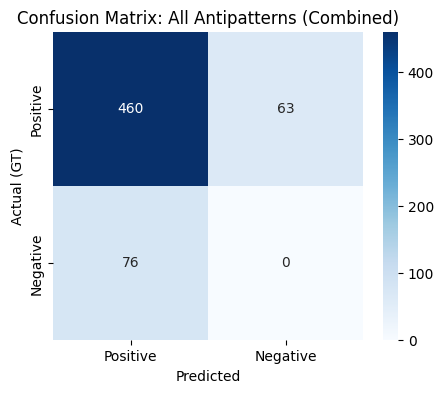

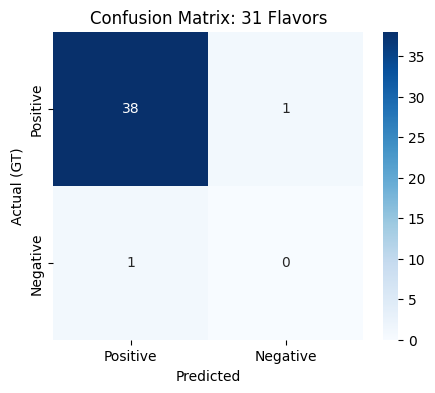

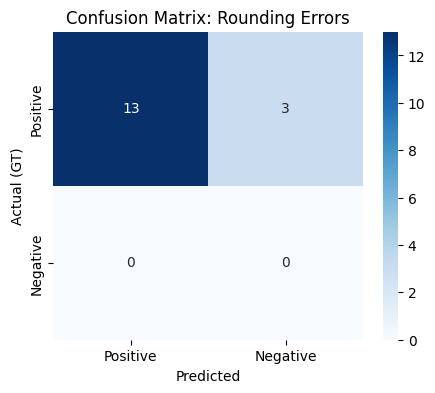

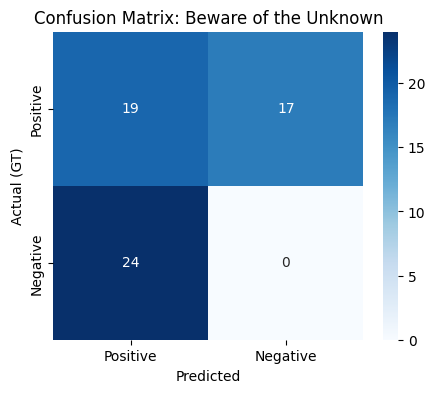

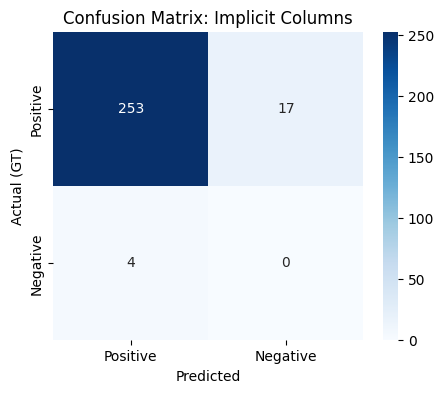

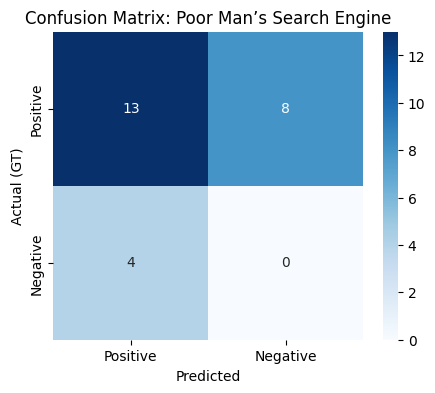

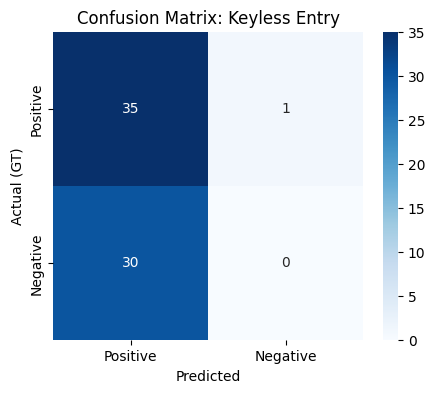

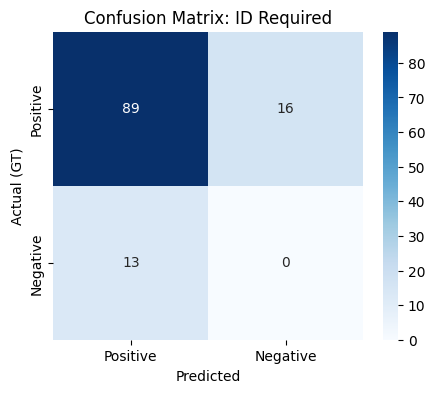

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_ap_confusion_matrix(tp, fp, fn, title):
    """
    Plots a 2x2 confusion matrix with Positive (Hit) at the top-left.
    Layout:
    [ TP , FN ]
    [ FP , TN ]
    """
    # Structure: [[TP, FN], [FP, TN]]
    # TN is 0 because it's not applicable in interval matching
    cm = np.array([[tp, fn], [fp, 0]])
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Positive', 'Negative'], 
                yticklabels=['Positive', 'Negative'])
    
    plt.ylabel('Actual (GT)')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix: {title}')
    plt.show()

# --- Calculate Data for Confusion Matrices ---
ap_stats = {}
global_tp = 0
global_fp = 0
global_fn = 0

for ap in all_antipatterns:
    ap_tp = 0 
    ap_fn = 0 
    ap_fp = 0 
    
    gt_subset = ground_truth_df[ground_truth_df['Antipattern'] == ap]
    pred_subset = results_df[results_df['Antipattern'] == ap]
    
    relevant_keys = set(zip(gt_subset['Project'], gt_subset['File'])).union(
                    set(zip(pred_subset['Project'], pred_subset['File'])))
    
    for (proj, filename) in relevant_keys:
        gts = gt_subset[(gt_subset['Project'] == proj) & (gt_subset['File'] == filename)][['Line from', 'Line to']].values.tolist()
        preds = pred_subset[(pred_subset['Project'] == proj) & (pred_subset['File'] == filename)][['Line from', 'Line to']].values.tolist()
        
        tp_rec, tp_prec = calculate_counts(gts, preds, threshold=0.5)
        
        ap_tp += tp_rec
        ap_fn += (len(gts) - tp_rec)
        ap_fp += (len(preds) - tp_prec)

    ap_stats[ap] = {'tp': ap_tp, 'fp': ap_fp, 'fn': ap_fn}
    
    global_tp += ap_tp
    global_fp += ap_fp
    global_fn += ap_fn

# --- Rendering ---

# 1. Global Confusion Matrix
plot_ap_confusion_matrix(global_tp, global_fp, global_fn, "All Antipatterns (Combined)")

# 2. Individual Confusion Matrices
for ap, stats in ap_stats.items():
    plot_ap_confusion_matrix(stats['tp'], stats['fp'], stats['fn'], ap)

In [27]:
missing_from_results = []

for index, gt_row in ground_truth_df.iterrows():
    # Filter results for the same Project, File, and Antipattern
    matches = results_df[
        (results_df['Project'] == gt_row['Project']) &
        (results_df['File'] == gt_row['File']) &
        (results_df['Antipattern'] == gt_row['Antipattern'])
    ]
    
    # Check if any of those matches meet the IoU threshold
    gt_interval = (gt_row['Line from'], gt_row['Line to'])
    is_found = any(
        iou_1d_inclusive(gt_interval, (p_row['Line from'], p_row['Line to'])) >= 0.5
        for _, p_row in matches.iterrows()
    )
    
    if not is_found:
        missing_from_results.append(gt_row)

# Create a DataFrame of the missing instances
missing_df = pd.DataFrame(missing_from_results)

# Display or save
print(f"Found {len(missing_df)} instances in Ground Truth not matched in Results.")
missing_df

Found 63 instances in Ground Truth not matched in Results.


,Project,Antipattern,File,Line from,Line to,Comment
0,Andrey582_NotificationBot,ID Required,scrapper/src/main/java/edu/java/database/jooq/tables/Chat.java,64,64,"createField(DSL.name(""id"") suured tähed"
2,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqChatRepository.java,21,21,.returning()
3,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqChatRepository.java,29,29,.returning()
6,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqChatToLinkRepository.java,28,28,.returning()
7,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqChatToLinkRepository.java,38,38,.returning()
8,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqChatToLinkRepository.java,48,48,.returning()
13,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqLinkRepository.java,25,25,.returning()
14,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqLinkRepository.java,33,33,.returning()
15,Andrey582_NotificationBot,Implicit Columns,scrapper/src/main/java/edu/java/database/jooq/repository/JooqLinkRepository.java,43,43,.returning()
20,balazskrizsan_stackjudge_aws_java,Beware of the Unknown,src/main/java/com/kbalazsworks/stackjudge_aws/db/tables/RemoteFiles.java,54,54,Should be non-nullable


In [28]:
results_not_in_gt = []

for index, pred_row in results_df.iterrows():
    # Filter ground truth for the same Project, File, and Antipattern
    potential_matches = ground_truth_df[
        (ground_truth_df['Project'] == pred_row['Project']) &
        (ground_truth_df['File'] == pred_row['File']) &
        (ground_truth_df['Antipattern'] == pred_row['Antipattern'])
    ]
    
    # Check if this prediction overlaps with ANY ground truth interval
    pred_interval = (pred_row['Line from'], pred_row['Line to'])
    is_valid = any(
        iou_1d_inclusive((gt_row['Line from'], gt_row['Line to']), pred_interval) >= 0.5
        for _, gt_row in potential_matches.iterrows()
    )
    
    # If no GT matches this prediction, it's an extra (Ghost) result
    if not is_valid:
        results_not_in_gt.append(pred_row)

# Create a DataFrame of the extra instances
ghosts_df = pd.DataFrame(results_not_in_gt)

# Display or save
print(f"Found {len(ghosts_df)} instances in Results that are not in Ground Truth.")
ghosts_df

Found 76 instances in Results that are not in Ground Truth.


,Project,Antipattern,File,Line from,Line to,Explanation
28,gonzo1138_jOOQinSpring-basics,Implicit Columns,src/main/java/org/anisation/jooqbasics/DbAccess.java,28,28,"Using `select()` without specifying columns fetches all columns from DATABASE_ENTITY, which can retrieve unnecessary data and cause maintenance issues if the table schema changes. Specify only the required columns explicitly, e.g., `jooq.select(DATABASE_ENTITY.ID, DATABASE_ENTITY.TEXT_FIELD).from(DATABASE_ENTITY)`."
51,kaeru61_chat_app,Beware of the Unknown,src/main/java/com/chatapp/jooq/com/chatapp/jooq/tables/ChatRooms.java,71,71,"The 'created_at' column has a default value but is marked as NULLABLE (no .nullable(false) specified), even though it will always have a value in practice. Consider adding .nullable(false) to the column definition to enforce data integrity."
52,kaeru61_chat_app,Beware of the Unknown,src/main/java/com/chatapp/jooq/com/chatapp/jooq/tables/ChatRooms.java,76,76,"The 'is_deleted' column has a default value of 'false' but is marked as NULLABLE, even though it should always have a boolean value. Consider adding .nullable(false) to ensure the column always contains a valid boolean value."
53,kaeru61_chat_app,Beware of the Unknown,src/main/java/com/chatapp/jooq/com/chatapp/jooq/tables/ChatRooms.java,81,81,"The 'is_private' column has a default value of 'false' but is marked as NULLABLE, even though it should always have a boolean value. Consider adding .nullable(false) to ensure the column always contains a valid boolean value."
55,kaeru61_chat_app,Beware of the Unknown,src/main/java/com/chatapp/jooq/com/chatapp/jooq/tables/ChatRoomUsers.java,75,75,"The 'created_at' column has a default value (CURRENT_TIMESTAMP) but is marked as NULLABLE, which is inconsistent since it will always have a value in practice. Consider adding .nullable(false) to the column definition to enforce the NOT NULL constraint."
57,kaeru61_chat_app,Beware of the Unknown,src/main/java/com/chatapp/jooq/com/chatapp/jooq/tables/Messages.java,80,80,"The 'created_at' column has a default value but is marked as NULLABLE (no explicit nullable(false)), which means it can never be NULL in practice but the schema allows it. Add .nullable(false) to the column definition to enforce the NOT NULL constraint."
58,kaeru61_chat_app,Beware of the Unknown,src/main/java/com/chatapp/jooq/com/chatapp/jooq/tables/Users.java,77,77,"The CREATED_AT column has a default value but is marked as NULLABLE, which means it can never be NULL in practice since it will always default to CURRENT_TIMESTAMP. Mark this column as NOT NULL to accurately reflect its intended usage."
59,killbill_killbill-stripe-plugin,ID Required,src/main/java/org/killbill/billing/plugin/stripe/dao/gen/tables/StripeHppRequests.java,56,56,The table has a synthetic auto-increment primary key (RECORD_ID) even though it already has a natural unique key on SESSION_ID (KEY_STRIPE_HPP_REQUESTS_STRIPE_HPP_REQUESTS_KB_SESSION_ID). Consider using SESSION_ID as the primary key since it uniquely identifies each record and is a stable business identifier.
60,killbill_killbill-stripe-plugin,ID Required,src/main/java/org/killbill/billing/plugin/stripe/dao/gen/tables/StripePaymentMethods.java,56,56,The table uses a synthetic auto-increment primary key (RECORD_ID) even though there's already a unique constraint on KB_PAYMENT_METHOD_ID which is a natural key suitable as a primary key. Consider using KB_PAYMENT_METHOD_ID as the primary key instead of the synthetic RECORD_ID column.
71,linux-china_jooq-demo,Keyless Entry,src/main/java/org/mvnsearch/infrastructure/jooq/tables/BookToBookStore.java,61,61,The 'book_id' column references the 'book' table but lacks a foreign key constraint. Add a foreign key constraint referencing the book table's id column (KEY_BOOK_PRIMARY) to ensure referential integrity.


In [ ]:
Date	Slug	Usage	BYOK Usage	Requests	Prompt Tokens	Completion Tokens	Reasoning Tokens	API Key
2026-04-04 15:00:00	anthropic/claude-opus-4.5	14.34146	0	502	2433632	86932	0	Unknown
